Обучите простую рекуррентную нейронную сеть (без GRU/LSTM, без внимания) решать задачу дешифровки шифра Цезаря:

Написать алгоритм шифра Цезаря для генерации выборки (сдвиг на N каждой буквы). Например если N=2, то буква A переходит в букву C. Можно поиграться с языком на выбор (немецкий, русский и т.д.)

Создать архитектуру рекуррентной нейронной сети.

Обучить ее (вход - зашифрованная фраза, выход - дешифрованная фраза).

Проверить качество модели. 

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, TimeDistributed
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import string

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
class CaesarCipherDataGenerator:
    """
    Generate data for Caesar cipher encryption/decryption
    """
    def __init__(self, chars=string.ascii_lowercase + ' ', max_length=20):
        self.chars = chars
        self.char_to_idx = {char: idx for idx, char in enumerate(chars)}
        self.idx_to_char = {idx: char for idx, char in enumerate(chars)}
        self.vocab_size = len(chars)
        self.max_length = max_length
    
    def caesar_encrypt(self, text, shift):
        encrypted = []
        for char in text:
            if char in self.char_to_idx:
                idx = self.char_to_idx[char]
                # Shift and wrap around
                new_idx = (idx + shift) % self.vocab_size
                encrypted.append(self.idx_to_char[new_idx])
            else:
                encrypted.append(char)
        return ''.join(encrypted)
    
    def generate_batch(self, batch_size=32):
        """Generate a batch of (encrypted, original) text pairs"""
        X = np.zeros((batch_size, self.max_length, self.vocab_size))
        y = np.zeros((batch_size, self.max_length, self.vocab_size))
        
        for i in range(batch_size):
            # Generate random text
            length = np.random.randint(3, self.max_length)
            text = ''.join(np.random.choice(list(self.chars), length))
            
            # Random shift between 1 and vocab_size-1
            shift = np.random.randint(1, self.vocab_size)
            
            # Encrypt
            encrypted = self.caesar_encrypt(text, shift)
            
            # Pad sequences
            text_padded = text.ljust(self.max_length)
            encrypted_padded = encrypted.ljust(self.max_length)
            
            # One-hot encode
            for t, char in enumerate(encrypted_padded):
                X[i, t, self.char_to_idx[char]] = 1
            for t, char in enumerate(text_padded):
                y[i, t, self.char_to_idx[char]] = 1
        
        return X, y
    
    def text_to_sequence(self, text):
        """Convert text to one-hot encoded sequence"""
        padded = text.ljust(self.max_length)[:self.max_length]
        seq = np.zeros((self.max_length, self.vocab_size))
        for t, char in enumerate(padded):
            if char in self.char_to_idx:
                seq[t, self.char_to_idx[char]] = 1
        return seq
    
    def sequence_to_text(self, sequence):
        """Convert one-hot sequence back to text"""
        indices = np.argmax(sequence, axis=-1)
        text = ''.join([self.idx_to_char[idx] for idx in indices])
        return text.strip()


In [4]:
def create_simple_rnn_model(vocab_size, max_length, rnn_units=128):
    """
    Create a simple RNN model for Caesar cipher decryption
    """
    model = Sequential([
        # Simple RNN layer (not LSTM/GRU)
        SimpleRNN(rnn_units, 
                 return_sequences=True, 
                 input_shape=(max_length, vocab_size),
                 activation='tanh'),
        
        # Output layer for each time step
        TimeDistributed(Dense(vocab_size, activation='softmax'))
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


In [5]:
def decode_caesar(model, encrypted_text, data_generator):
    """
    Decode a single encrypted text using the trained model
    """
    # Convert to sequence
    X = data_generator.text_to_sequence(encrypted_text)
    X_batch = np.expand_dims(X, axis=0)
    
    # Predict
    predictions = model.predict(X_batch, verbose=0)[0]
    
    # Convert back to text
    decoded = data_generator.sequence_to_text(predictions)
    
    return decoded

In [6]:
def train_model():
    """
    Train the RNN model for Caesar cipher decryption
    """
    # Initialize data generator
    data_gen = CaesarCipherDataGenerator()
    
    # Create model
    model = create_simple_rnn_model(
        vocab_size=data_gen.vocab_size,
        max_length=data_gen.max_length,
        rnn_units=128
    )
    
    print("Model Architecture:")
    model.summary()
    
    # Training parameters
    epochs = 30
    batch_size = 64
    steps_per_epoch = 200
    
    # Training history
    history = {'loss': [], 'accuracy': []}
    
    print("\nStarting training...")
    for epoch in range(epochs):
        epoch_loss = []
        epoch_acc = []
        
        for step in range(steps_per_epoch):
            # Generate batch
            X_batch, y_batch = data_gen.generate_batch(batch_size)
            
            # Train on batch
            loss, acc = model.train_on_batch(X_batch, y_batch)
            epoch_loss.append(loss)
            epoch_acc.append(acc)
        
        # Average metrics for epoch
        avg_loss = np.mean(epoch_loss)
        avg_acc = np.mean(epoch_acc)
        history['loss'].append(avg_loss)
        history['accuracy'].append(avg_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")
        
        # Test on a sample every 5 epochs
        if (epoch + 1) % 5 == 0:
            test_text = "hello world"
            shift = 3
            encrypted = data_gen.caesar_encrypt(test_text, shift)
            decoded = decode_caesar(model, encrypted, data_gen)
            print(f"  Test: '{encrypted}' (shift={shift}) -> '{decoded}'")
    
    return model, data_gen, history

In [7]:
def demonstrate_decoding(model, data_gen, test_cases):
    """
    Demonstrate the model's decoding capabilities on various test cases
    """
    print("\n" + "="*50)
    print("DECODING DEMONSTRATION")
    print("="*50)
    
    for test_text in test_cases:
        print(f"\nOriginal: '{test_text}'")
        
        # Try different shifts
        for shift in [3, 10, 15]:
            encrypted = data_gen.caesar_encrypt(test_text, shift)
            decoded = decode_caesar(model, encrypted, data_gen)
            
            print(f"  Shift {shift:2d}: '{encrypted}' -> '{decoded}'")
            
            # Check if decoded correctly (ignoring padding)
            original_trimmed = test_text.strip()
            decoded_trimmed = decoded.strip()
            correct = original_trimmed == decoded_trimmed
            
            print(f"    {'✓' if correct else '✗'} Correct: {correct}")

In [8]:
def plot_training_history(history):
    """
    Plot training loss and accuracy over time
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history['loss'])
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    
    ax2.plot(history['accuracy'])
    ax2.set_title('Training Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

Model Architecture:


C:\Users\user\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 20, 128)             │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 20, 27)              │           3,483 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,451 (91.61 KB)

 Trainable params: 23,451 (91.61 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/30 - Loss: 2.1080, Accuracy: 0.4408
Epoch 2/30 - Loss: 1.9429, Accuracy: 0.4627
Epoch 3/30 - Loss: 1.9125, Accuracy: 0.4647
Epoch 4/30 - Loss: 1.8973, Accuracy: 0.4660
Epoch 5/30 - Loss: 1.8885, Accuracy: 0.4667
  Test: 'khoorczruog' (shift=3) -> 'zqrexeenfel'
Epoch 6/30 - Loss: 1.8816, Accuracy: 0.4673
Epoch 7/30 - Loss: 1.8762, Accuracy: 0.4679
Epoch 8/30 - Loss: 1.8739, Accuracy: 0.4678
Epoch 9/30 - Loss: 1.8719, Accuracy: 0.4677
Epoch 10/30 - Loss: 1.8692, Accuracy: 0.4680
  Test: 'khoorczruog' (shift=3) -> 'epmfjaouodr'
Epoch 11/30 - Loss: 1.8672, Accuracy: 0.4682
Epoch 12/30 - Loss: 1.8654, Accuracy: 0.4683
Epoch 13/30 - Loss: 1.8633, Accuracy: 0.4686
Epoch 14/30 - Loss: 1.8608, Accuracy: 0.4690
Epoch 15/30 - Loss: 1.8598, Accuracy: 0.4690
  Test: 'khoorczruog' (shift=3) -> 'bdp  eonb y'
Epoch 16/30 - Loss: 1.8585, Accuracy: 0.4691
Epoch 17/30 - Loss: 1.8573, Accuracy: 0.4692
Epoch 18/30 - Loss: 1.8564, Accuracy: 0.4693
Epoch 19/30 - Loss: 1.8558, Ac

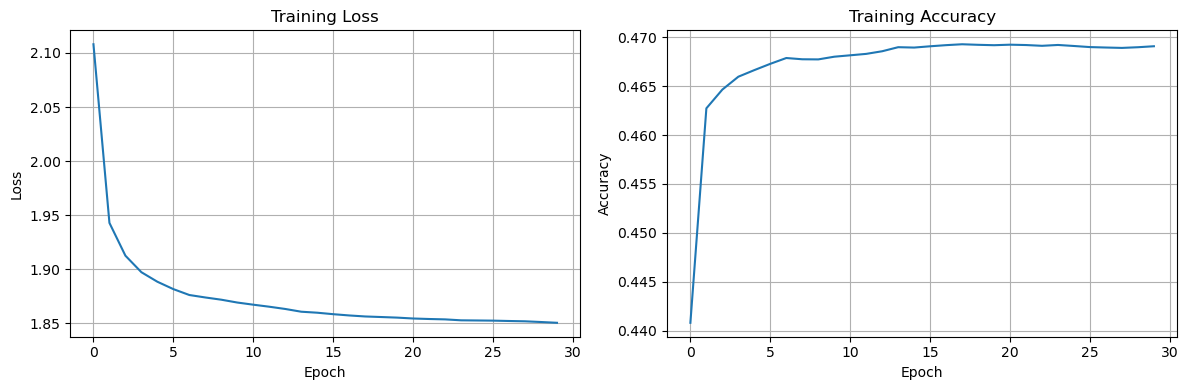


DECODING DEMONSTRATION

Original: 'hello'
  Shift  3: 'khoor' -> 'ctp x'
    ✗ Correct: False
  Shift 10: 'rovvy' -> 'fumse'
    ✗ Correct: False
  Shift 15: 'wt  c' -> 'gk'
    ✗ Correct: False

Original: 'world'
  Shift  3: 'zruog' -> 'sfab'
    ✗ Correct: False
  Shift 10: 'fyavn' -> 'yeuse'
    ✗ Correct: False
  Shift 15: 'kcf s' -> 'cyy'
    ✗ Correct: False

Original: 'python'
  Shift  3: 'sawkrq' -> 'qugcwu'
    ✗ Correct: False
  Shift 10: 'zhcryx' -> 'szyjcq'
    ✗ Correct: False
  Shift 15: 'dmhwcb' -> 'febpot'
    ✗ Correct: False

Original: 'machine learning'
  Shift  3: 'pdfklqhcohduqlqj' -> 'jpycejdwfzjjjdjy'
    ✗ Correct: False
  Shift 10: 'wkmrsxojvokaxsxq' -> 'gce uq xijyjo y'
    ✗ Correct: False
  Shift 15: 'aprwxbto tpfbxbv' -> 'ulmre kf  txdk'
    ✗ Correct: False

Original: 'artificial intelligence'
  Shift  3: 'duwlilfldoclqwhooljhqfh' -> 'fegdbgeijjytjn   ye'
    ✗ Correct: False
  Shift 10: 'kacspsmskvjsxcovvsqoxmo' -> 'cuy ijejnjeilyvyje'
    ✗ Correct: Fal


Enter text (lowercase letters and spaces only):  hello
Enter shift (1-26):  5


Encrypted: 'mjqqt'
Decrypted (by RNN): 'ecijd'
Original: 'hello'
Correct: False



Enter text (lowercase letters and spaces only):  quit


In [9]:
# Main execution
if __name__ == "__main__":
    # Train the model
    model, data_gen, history = train_model()
    
    # Plot training progress
    plot_training_history(history)
    
    # Test cases for demonstration
    test_cases = [
        "hello",
        "world",
        "python",
        "machine learning",
        "artificial intelligence"
    ]
    
    # Demonstrate decoding
    demonstrate_decoding(model, data_gen, test_cases)
    
    # Interactive demo
    print("\n" + "="*50)
    print("INTERACTIVE DEMO")
    print("="*50)
    print("Enter text to encrypt and decrypt (or 'quit' to exit)")
    
    while True:
        text = input("\nEnter text (lowercase letters and spaces only): ").lower()
        if text == 'quit':
            break
        
        try:
            shift = int(input("Enter shift (1-26): "))
            if shift < 1 or shift > 26:
                print("Shift must be between 1 and 26")
                continue
        except ValueError:
            print("Please enter a valid number")
            continue
        
        # Encrypt
        encrypted = data_gen.caesar_encrypt(text, shift)
        print(f"Encrypted: '{encrypted}'")
        
        # Decrypt using model
        decoded = decode_caesar(model, encrypted, data_gen)
        print(f"Decrypted (by RNN): '{decoded.strip()}'")
        
        # Compare with original
        print(f"Original: '{text}'")
        print(f"Correct: {text.strip() == decoded.strip()}")